          mean         sum  count
hour                             
11    0.962718   488.09785    507
12   -1.288122  -556.46865    432
13    3.515452  1216.34635    346
14    2.697493   420.80885    156

Chart saved to hourly_pnl_11_14.png


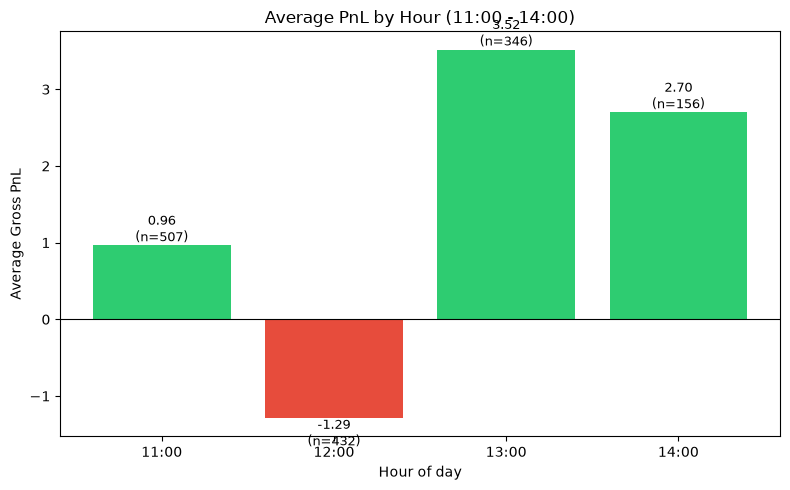

In [2]:
"""
Visualize average PnL by hour (11:00 - 14:00 window).

Expects a CSV/Excel file with at least these columns:
    entry_timestamp   (any parseable datetime string)
    gross_pnl         (numeric)

Set TRADES_PATH below and just run the script (no CLI args needed).
"""

import pandas as pd
import matplotlib.pyplot as plt

# <-- set your file path here
TRADES_PATH = r"D:\FM\ALGOTRADING\artifacts\backtest_reports\VWAPStrategy\20260926-154305\trades.csv"

def load_data(path):
    if path.lower().endswith(('.xlsx', '.xls')):
        return pd.read_excel(path)
    return pd.read_csv(path)

def main(path):
    df = load_data(path)

    # Keep only what we need
    df = df[['entry_timestamp', 'gross_pnl']].copy()
    df['entry_timestamp'] = pd.to_datetime(df['entry_timestamp'])
    df['hour'] = df['entry_timestamp'].dt.hour

    # Filter to the 11:00–14:00 window (hours 11, 12, 13, 14)
    window = df[(df['hour'] >= 11) & (df['hour'] <= 14)]

    if window.empty:
        print("No trades found between 11:00 and 14:00.")
        return

    # Aggregate per hour
    hourly = window.groupby('hour')['gross_pnl'].agg(['mean', 'sum', 'count'])
    hourly = hourly.reindex(range(11, 15))  # ensure all 4 hours show, even if 0 trades
    print(hourly)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(
        [f"{h}:00" for h in hourly.index],
        hourly['mean'].fillna(0),
        color=['#2ecc71' if v >= 0 else '#e74c3c' for v in hourly['mean'].fillna(0)]
    )

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Average PnL by Hour (11:00 - 14:00)')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Average Gross PnL')

    # Label bars with value + trade count
    for bar, (h, row) in zip(bars, hourly.iterrows()):
        count = int(row['count']) if pd.notna(row['count']) else 0
        label = f"{row['mean']:.2f}\n(n={count})" if pd.notna(row['mean']) else "n=0"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            label,
            ha='center',
            va='bottom' if bar.get_height() >= 0 else 'top',
            fontsize=9
        )

    plt.tight_layout()
    out_path = 'hourly_pnl_11_14.png'
    plt.savefig(out_path, dpi=150)
    print(f"\nChart saved to {out_path}")
    plt.show()

if __name__ == '__main__':
    main(TRADES_PATH)